
Running for 6 qubits (Nx = 64)


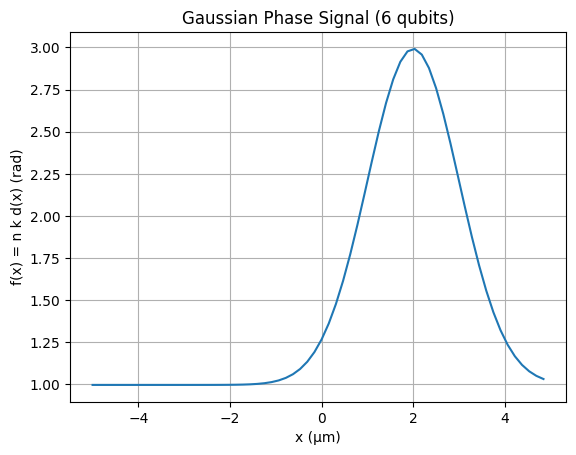


Running for 7 qubits (Nx = 128)


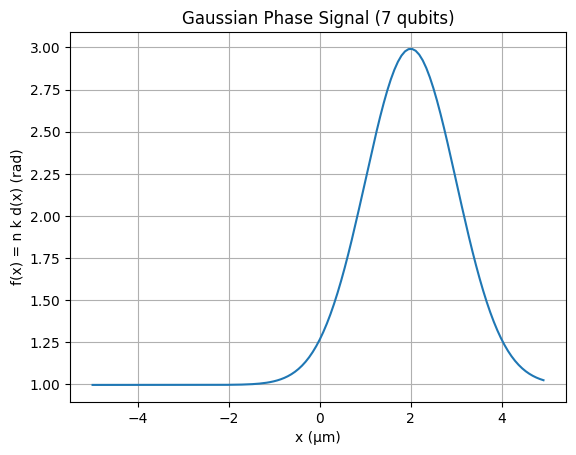


Running for 8 qubits (Nx = 256)


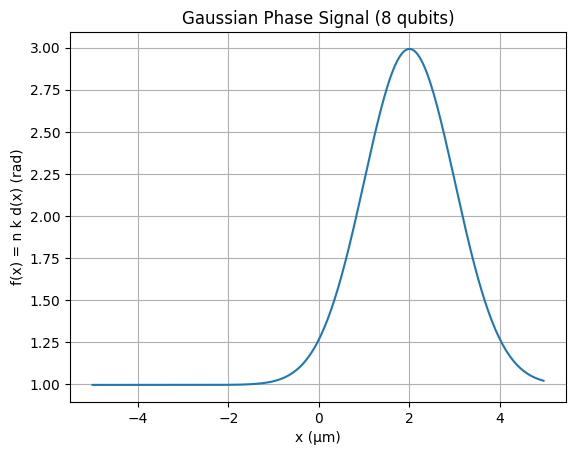


Running for 9 qubits (Nx = 512)


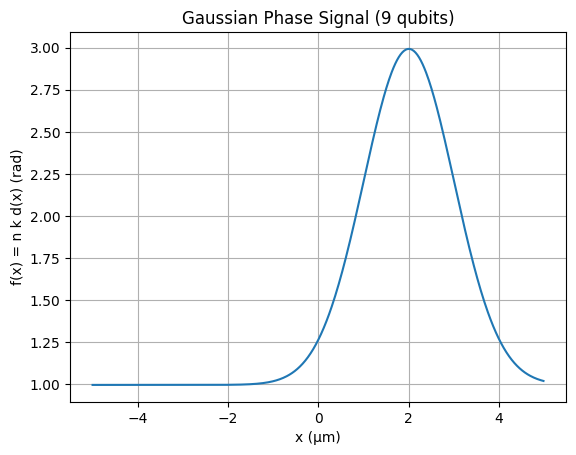

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def spatial_grid(L, Nx):
    return np.linspace(-L/2, L/2, Nx, endpoint=False)

def gaussian_thickness_profile(x, d0, h, sigma, x0=0):
    return d0 + h * np.exp(-((x - x0)**2) / (2 * sigma**2))

def phase_signal(d, n, lam):
    k = 2*np.pi / lam
    return n * k * d

def phi_from_f(f):
    alpha = np.sum(f)
    phi = np.sqrt(f / alpha)
    return phi, alpha

def plot_signal(x, f, n_qubits):
    plt.figure()
    plt.plot(x * 1e6, f)
    plt.xlabel("x (µm)")
    plt.ylabel("f(x) = n k d(x) (rad)")
    plt.title(f"Gaussian Phase Signal ({n_qubits} qubits)")
    plt.grid(True)
    plt.show()

# spatial parameters
T = 10e-6

# optical parameters
lam = 630e-9
n_refr = 1.0

# Gaussian parameters
d0 = 100e-9
h = 200e-9
sigma = 1e-6
x0 = 2e-6 # controls width

for n_qubits in range(6, 10):
    Nx = 2**n_qubits

    print(f"\nRunning for {n_qubits} qubits (Nx = {Nx})")

    x = spatial_grid(T, Nx)

    d = gaussian_thickness_profile(x, d0, h, sigma, x0=x0)

    f = phase_signal(d, n_refr, lam)

    phi, alpha = phi_from_f(f)

    plot_signal(x, f, n_qubits)

In [34]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
from qiskit.quantum_info import state_fidelity

sim = AerSimulator(method="statevector")

qubit_range = range(5, 10)      # 5, 6, 7, 8, 9 qubits
layer_range = range(1, 201)     # 1 to 200 layers
threshold = 0.99

best_layers = []
best_fidelities = []

for n_qubits in qubit_range:

    Nx = 2**n_qubits

    x = spatial_grid(T, Nx)
    d = gaussian_thickness_profile(x, d0, h, sigma, x0=x0)
    f = phase_signal(d, n_refr, lam)
    phi, _ = phi_from_f(f)

    phi = np.asarray(phi, dtype=complex)
    phi = phi / np.linalg.norm(phi)

    print(f"\nRunning for {n_qubits} qubits")

    reached_threshold = False

    for L in layer_range:

        phi_state = QuantumState.from_dense_data(data=phi, normalize=False)
        U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=L)

        qc = QuantumCircuit(n_qubits)
        qc.append(U_phi, range(n_qubits))
        qc.save_statevector()

        result = sim.run(transpile(qc, sim)).result()
        vec_sim = np.array(result.get_statevector(qc), dtype=complex)

        F = state_fidelity(vec_sim, phi)

        print(f"  Layers = {L}, Fidelity = {F:.6f}")

        if F >= threshold:
            print(f"  ✅ Threshold reached at layer {L}, Fidelity = {F:.6f}")
            best_layers.append(L)
            best_fidelities.append(F)
            reached_threshold = True
            break

    if not reached_threshold:
        print(f"  ❌ Threshold not reached up to 200 layers")
        best_layers.append(np.nan)
        best_fidelities.append(np.nan)


Running for 5 qubits
  Layers = 1, Fidelity = 0.999902
  ✅ Threshold reached at layer 1, Fidelity = 0.999902

Running for 6 qubits
  Layers = 1, Fidelity = 0.999784
  ✅ Threshold reached at layer 1, Fidelity = 0.999784

Running for 7 qubits
  Layers = 1, Fidelity = 0.998268
  ✅ Threshold reached at layer 1, Fidelity = 0.998268

Running for 8 qubits
  Layers = 1, Fidelity = 0.997733
  ✅ Threshold reached at layer 1, Fidelity = 0.997733

Running for 9 qubits
  Layers = 1, Fidelity = 0.997261
  ✅ Threshold reached at layer 1, Fidelity = 0.997261



Summary:
Qubits = 5, Best layer = 1, Fidelity = 0.9999020808186494
Qubits = 6, Best layer = 1, Fidelity = 0.9997841765379081
Qubits = 7, Best layer = 1, Fidelity = 0.998268066480566
Qubits = 8, Best layer = 1, Fidelity = 0.9977329855983148
Qubits = 9, Best layer = 1, Fidelity = 0.9972611696489804


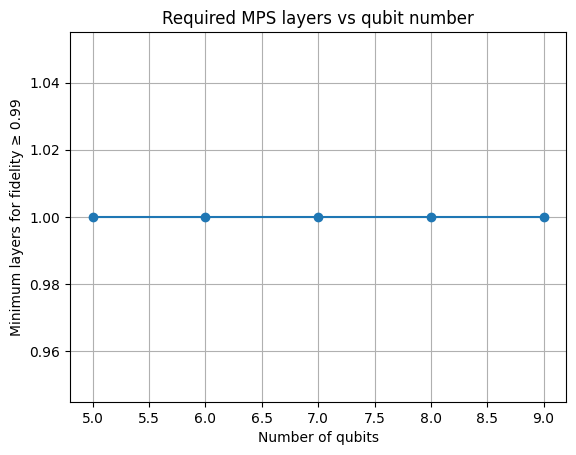

In [35]:
print("\nSummary:")
for q, L, F in zip(qubit_range, best_layers, best_fidelities):
    print(f"Qubits = {q}, Best layer = {L}, Fidelity = {F}")


plt.figure()
plt.plot(list(qubit_range), best_layers, marker="o")
plt.xlabel("Number of qubits")
plt.ylabel("Minimum layers for fidelity ≥ 0.99")
plt.title("Required MPS layers vs qubit number")
plt.grid(True)
plt.show()

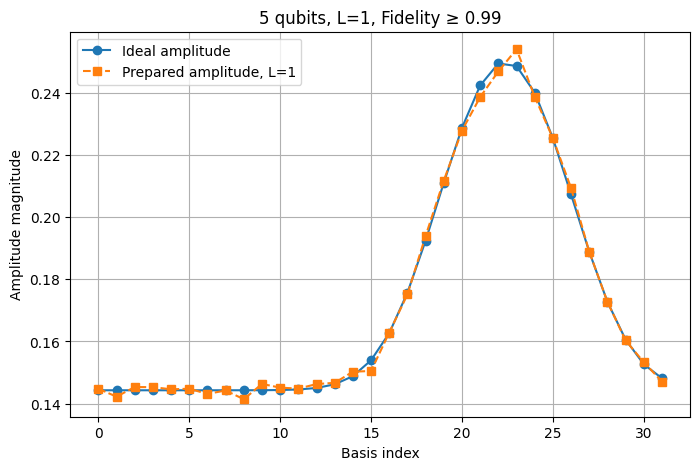

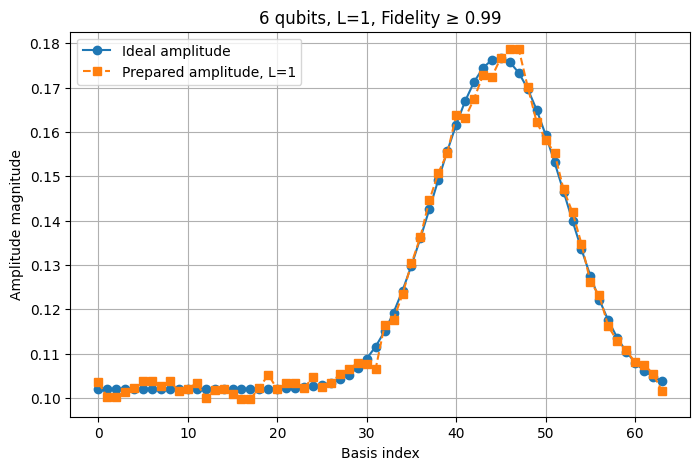

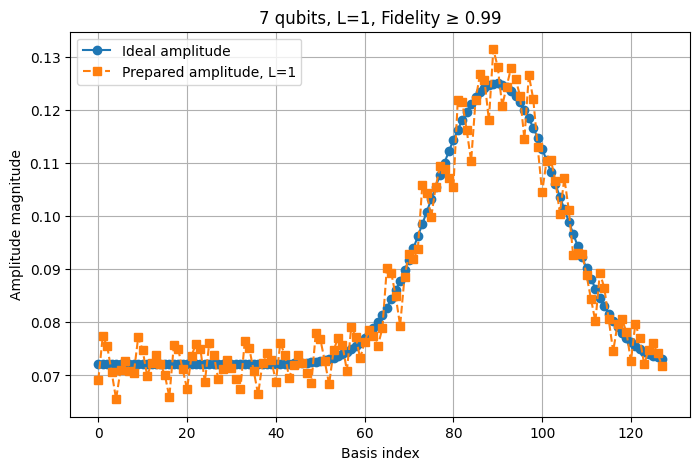

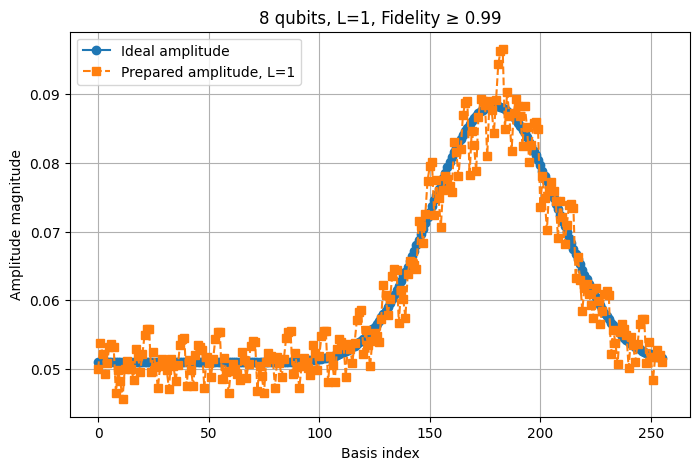

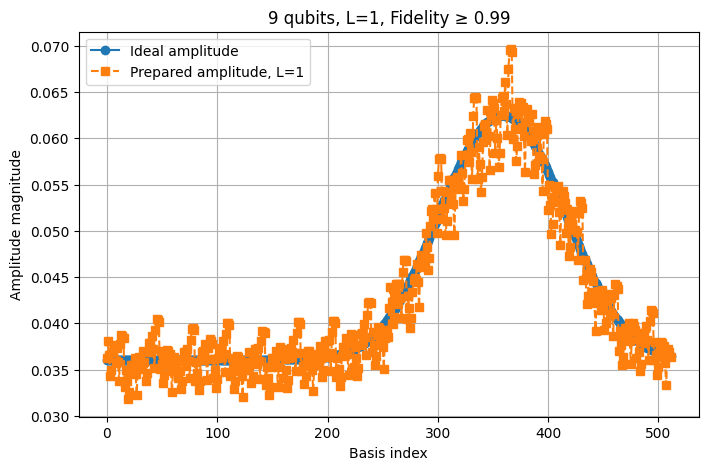

In [36]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState

sim = AerSimulator(method="statevector")

for qi, n_qubits in enumerate(qubit_range):
    chosen_layer = best_layers[qi]

    if np.isnan(chosen_layer):
        print(f"{n_qubits} qubits: fidelity {threshold} not reached.")
        continue

    Nx = 2**n_qubits

    # regenerate phi for this qubit count
    x = spatial_grid(T,Nx)
    d = gaussian_thickness_profile(x, d0, h, sigma, x0=x0)
    f = phase_signal(d, n_refr, lam)
    phi, _ = phi_from_f(f)

    phi = np.asarray(phi, dtype=complex)
    phi = phi / np.linalg.norm(phi)

    # build threshold-layer circuit
    phi_state = QuantumState.from_dense_data(data=phi, normalize=False)
    U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=int(chosen_layer))

    qc = QuantumCircuit(n_qubits)
    qc.append(U_phi, range(n_qubits))
    qc.save_statevector()

    result = sim.run(transpile(qc, sim)).result()
    vec_sim = np.array(result.get_statevector(qc), dtype=complex)

    # align global phase
    global_phase = np.angle(np.vdot(phi, vec_sim))
    vec_sim_aligned = vec_sim * np.exp(-1j * global_phase)

    amps_ideal = np.abs(phi)
    amps_sim = np.abs(vec_sim_aligned)

    plt.figure(figsize=(8, 5))
    plt.plot(range(Nx), amps_ideal, 'o-', label="Ideal amplitude")
    plt.plot(range(Nx), amps_sim, 's--', label=f"Prepared amplitude, L={int(chosen_layer)}")
    plt.xlabel("Basis index")
    plt.ylabel("Amplitude magnitude")
    plt.title(f"{n_qubits} qubits, L={int(chosen_layer)}, Fidelity ≥ {threshold}")
    plt.legend()
    plt.grid(True)
    plt.show()

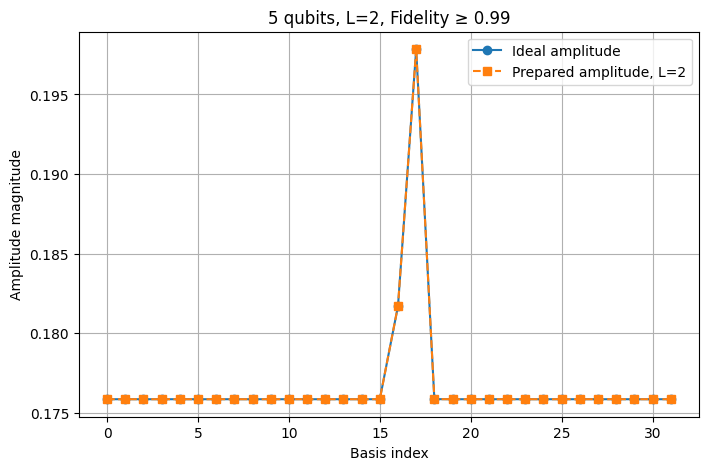

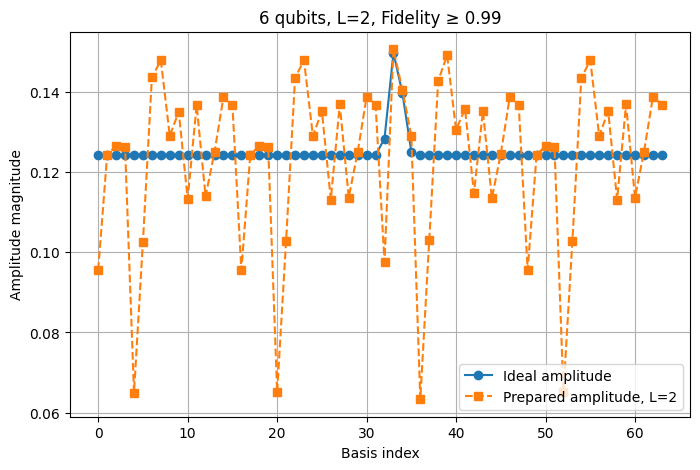

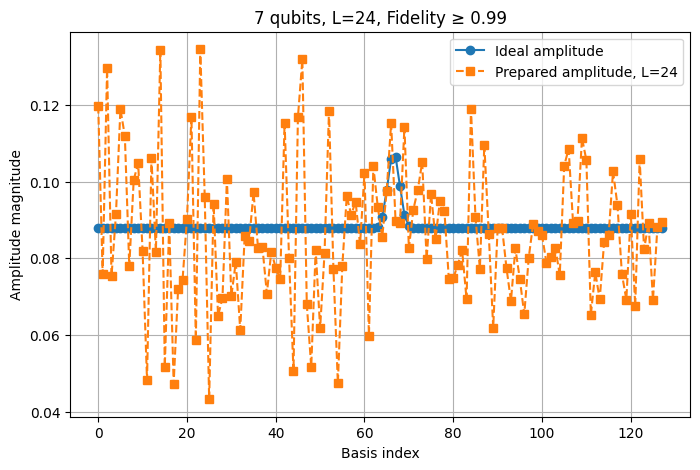

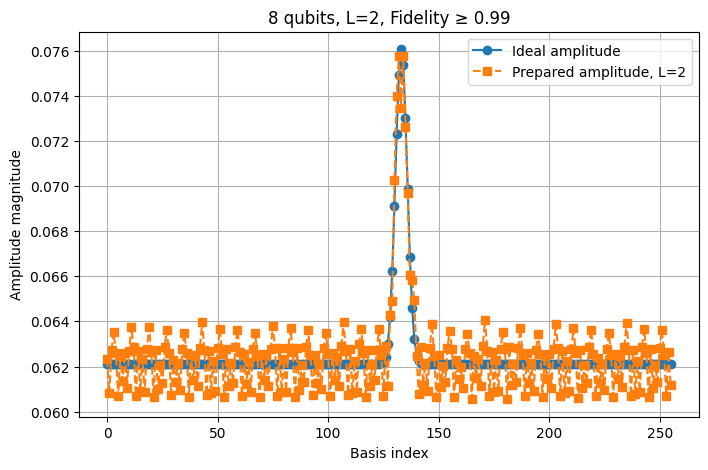

IndexError: list index out of range

In [37]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState

sim = AerSimulator(method="statevector")

for qi, n_qubits in enumerate(qubit_range):
    chosen_layer = layers_needed[qi]

    if np.isnan(chosen_layer):
        print(f"{n_qubits} qubits: fidelity {threshold} not reached.")
        continue

    Nx = 2**n_qubits

    # regenerate phi for this qubit count
    x = spatial_grid(T, Nx)
    d = gaussian_thickness_profile(x, x0, sigma, d0, h)
    f = phase_signal(d, n_refr, lam)
    phi, _ = phi_from_f(f)

    phi = np.asarray(phi, dtype=complex)
    phi = phi / np.linalg.norm(phi)

    # build threshold-layer circuit
    phi_state = QuantumState.from_dense_data(data=phi, normalize=False)
    U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=int(chosen_layer))

    qc = QuantumCircuit(n_qubits)
    qc.append(U_phi, range(n_qubits))
    qc.save_statevector()

    result = sim.run(transpile(qc, sim)).result()
    vec_sim = np.array(result.get_statevector(qc), dtype=complex)

    # align global phase
    global_phase = np.angle(np.vdot(phi, vec_sim))
    vec_sim_aligned = vec_sim * np.exp(-1j * global_phase)

    amps_ideal = np.abs(phi)
    amps_sim = np.abs(vec_sim_aligned)

    plt.figure(figsize=(8, 5))
    plt.plot(range(Nx), amps_ideal, 'o-', label="Ideal amplitude")
    plt.plot(range(Nx), amps_sim, 's--', label=f"Prepared amplitude, L={int(chosen_layer)}")
    plt.xlabel("Basis index")
    plt.ylabel("Amplitude magnitude")
    plt.title(f"{n_qubits} qubits, L={int(chosen_layer)}, Fidelity ≥ {threshold}")
    plt.legend()
    plt.grid(True)
    plt.show()